In [63]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv('/home/insurance.csv')

In [65]:
df=df.iloc[:, 0:5]

In [66]:
df.drop('sex', axis=1, inplace=True)

In [67]:
df

,age,bmi,children,smoker
0,19,27.9,0,yes
1,18,33.8,1,no
2,28,33.0,3,no
3,33,22.7,0,no
4,32,28.9,0,no
...,...,...,...,...
1333,50,31.0,3,no
1334,18,31.9,0,no
1335,18,36.9,0,no
1336,21,25.8,0,no


###Train test split

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('smoker', axis=1),
                                                    df['smoker'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((936, 3), (402, 3))

###StandardScaler

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


scaler.fit(X_train)

# transform
X_train_afterscaled = scaler.transform(X_train)
X_test_afterscaled = scaler.transform(X_test)

In [70]:
X_train

,age,bmi,children
1163,18,28.2,0
196,39,32.8,0
438,52,46.8,5
183,44,26.4,0
1298,33,27.5,2
...,...,...,...
763,27,26.0,0
835,42,36.0,2
1216,40,25.1,0
559,19,35.5,0


In [71]:
X_train_afterscaled

array([[-1.5330973 , -0.40984715, -0.89833872],
       [-0.03364163,  0.328248  , -0.89833872],
       [ 0.89459283,  2.57462454,  3.25603402],
       ...,
       [ 0.03776102, -0.90725909, -0.89833872],
       [-1.46169465,  0.76147776, -0.89833872],
       [-0.46205754, -1.96626518, -0.06746417]])

In [72]:
X_train_afterscaled = pd.DataFrame(X_train_afterscaled, columns=X_train.columns)
X_test_afterscaled = pd.DataFrame(X_test_afterscaled, columns=X_test.columns)

In [73]:
np.round(X_train.describe(), 1)

,age,bmi,children
count,936.0,936.0,936.0
mean,39.5,30.8,1.1
std,14.0,6.2,1.2
min,18.0,16.0,0.0
25%,27.0,26.4,0.0
50%,40.0,30.3,1.0
75%,52.0,34.8,2.0
max,64.0,53.1,5.0


In [74]:
np.round(X_train_afterscaled.describe(), 1)

,age,bmi,children
count,936.0,936.0,936.0
mean,-0.0,-0.0,0.0
std,1.0,1.0,1.0
min,-1.5,-2.4,-0.9
25%,-0.9,-0.7,-0.9
50%,0.0,-0.1,-0.1
75%,0.9,0.6,0.8
max,1.8,3.6,3.3


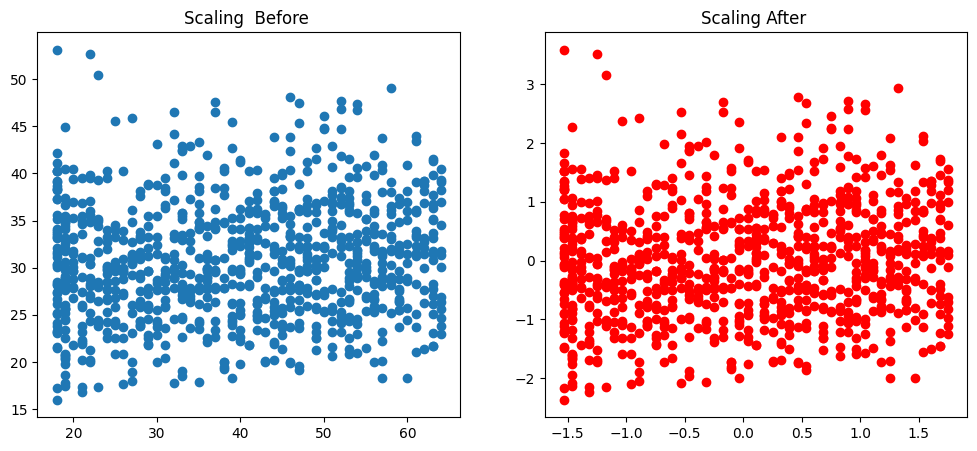

In [79]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['age'], X_train['bmi'])
ax1.set_title("Scaling  Before ")
ax2.scatter(X_train_afterscaled['age'], X_train_afterscaled['bmi'],color='red')
ax2.set_title("Scaling After ")
plt.show()

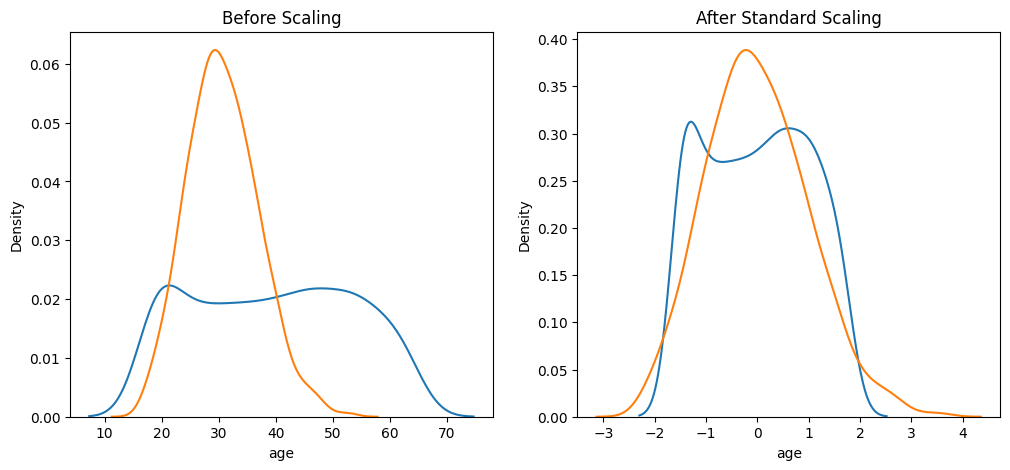

In [76]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Scaling Before ')
sns.kdeplot(X_train['age'], ax=ax1)
sns.kdeplot(X_train['bmi'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_afterscaled['age'], ax=ax2)
sns.kdeplot(X_train_afterscaled['bmi'], ax=ax2)
plt.show()

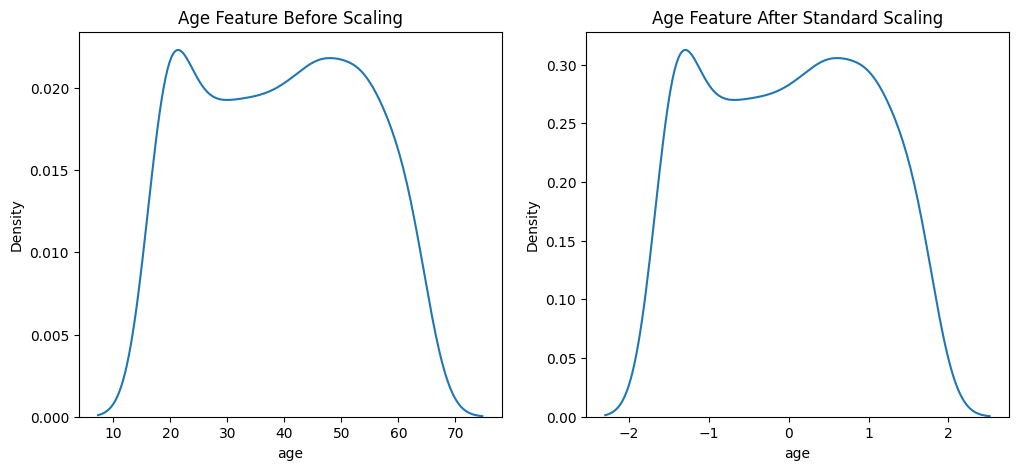

In [80]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Feature Before Scaling')
sns.kdeplot(X_train['age'], ax=ax1)

# after scaling
ax2.set_title('Age Feature After Standard Scaling')
sns.kdeplot(X_train_afterscaled['age'], ax=ax2)
plt.show()

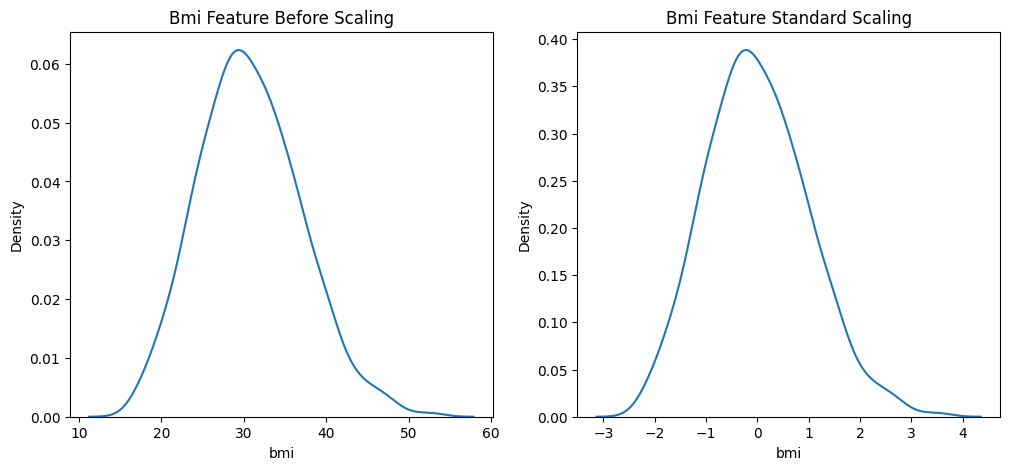

In [81]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Bmi Feature Before Scaling')
sns.kdeplot(X_train['bmi'], ax=ax1)

# after scaling
ax2.set_title('Bmi Feature Standard Scaling')
sns.kdeplot(X_train_afterscaled['bmi'], ax=ax2)
plt.show()

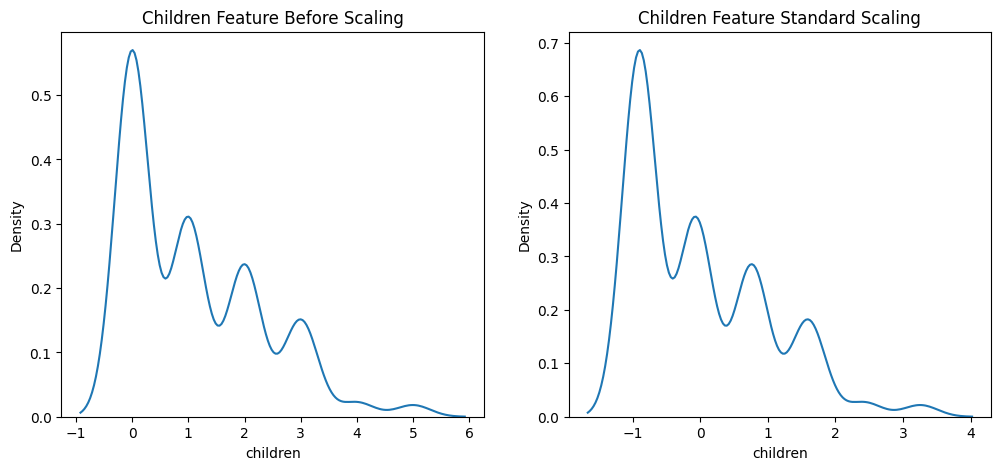

In [82]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Children Feature Before Scaling')
sns.kdeplot(X_train['children'], ax=ax1)

# after scaling
ax2.set_title('Children Feature Standard Scaling')
sns.kdeplot(X_train_afterscaled['children'], ax=ax2)
plt.show()

In [52]:
df.describe()

,age,bmi,children
count,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918
std,14.049960,6.098382,1.205493
min,18.000000,16.000000,0.000000
25%,27.000000,26.300000,0.000000
50%,39.000000,30.400000,1.000000
75%,51.000000,34.700000,2.000000
max,64.000000,53.100000,5.000000


In [54]:
df = pd.concat([
    df,
    pd.DataFrame({
        'age': [5, 80, 85],
        'bmi': [25, 90, 95],
        'children': [2, 7, 8]
    })
], ignore_index=True)

In [56]:
df.describe()

,age,bmi,children
count,1341.000000,1341.000000,1341.000000
mean,39.246085,30.753468,1.105145
std,14.164671,6.545171,1.229663
min,5.000000,16.000000,0.000000
25%,27.000000,26.300000,0.000000
50%,39.000000,30.400000,1.000000
75%,51.000000,34.700000,2.000000
max,85.000000,95.000000,8.000000


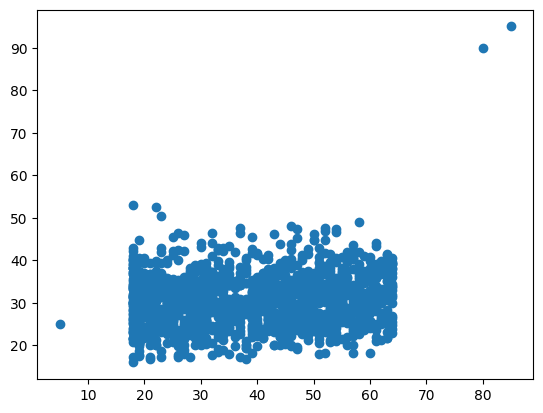

In [57]:
plt.scatter(df['age'], df['bmi'])

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('smoker', axis=1),
                                                    df['smoker'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((938, 3), (403, 3))

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


scaler.fit(X_train)


X_train_afterscaledForOutlier = scaler.transform(X_train)
X_test_afterscaledForOutlier = scaler.transform(X_test)

In [84]:
X_train_afterscaledForOutlier = pd.DataFrame(X_train_afterscaledForOutlier, columns=X_train.columns)
X_test_afterscaledForOutlier = pd.DataFrame(X_test_afterscaledForOutlier, columns=X_test.columns)

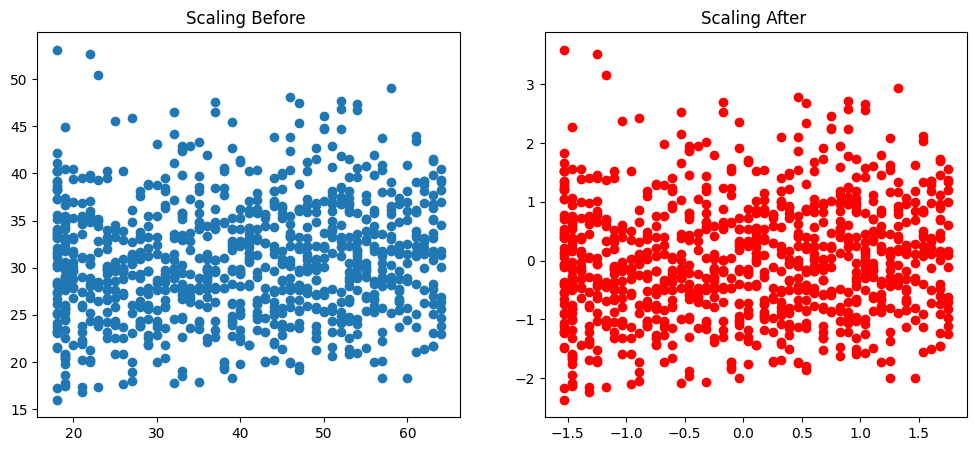

In [85]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['age'], X_train['bmi'])
ax1.set_title("Scaling Before ")
ax2.scatter(X_train_afterscaledForOutlier['age'], X_train_afterscaledForOutlier['bmi'],color='red')
ax2.set_title("Scaling After ")
plt.show()